# Decision tree
## 1. Entropy(
 - measure the randomness
 - range(0-1)
 - sum([ilog2(pi))
## 2. Information Gain 
- ig=entropy of parent - entropy of chld
- Higher IG =bettter split
## 3. Gini index
-use to meausure empurity of data 
Gini = 1-SUMpi^2
pure node=0
maximum impurity =0.5(binary)
lower Gini =better split

# cart 
  gini minimum 



In [33]:
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df= pd.read_csv("Salary_dataset.csv")

In [35]:
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [36]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
x=df[['YearsExperience']]
y=df['Salary']

In [39]:
X_train , X_test , y_train, y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [40]:
dt=DecisionTreeRegressor() #mae ,mse 

In [41]:
dt.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [42]:
y_pred = dt.predict(X_test)

In [43]:
dt.score(X_train, y_train)

0.9999631319936537

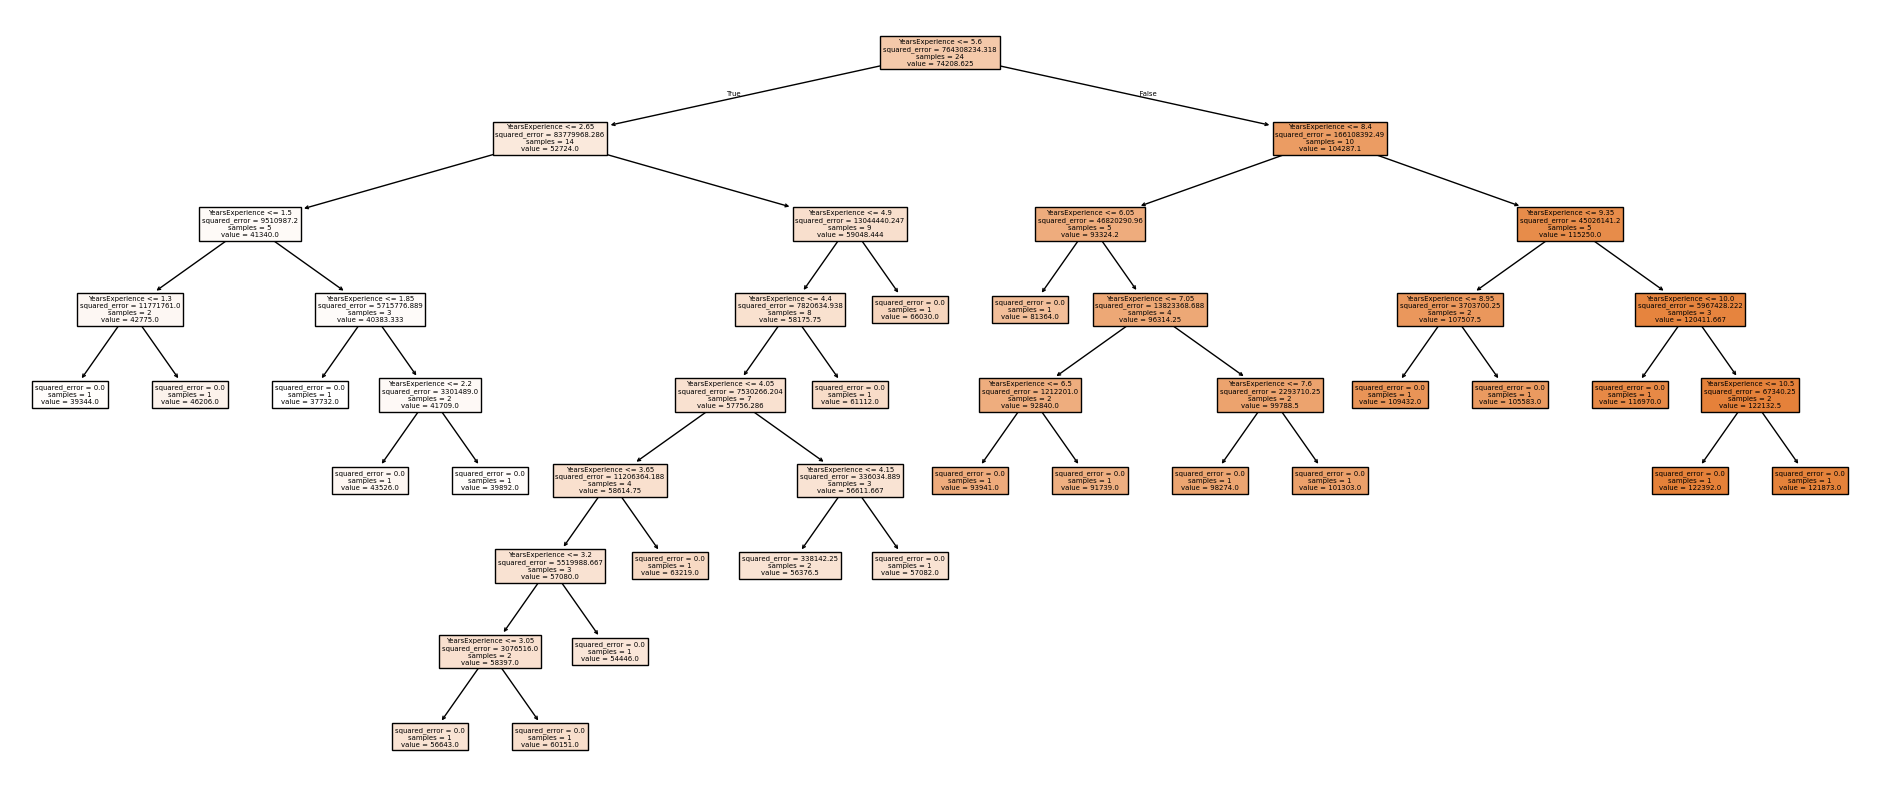

In [44]:
plt.figure(figsize=(24,10))
tree.plot_tree(
    dt,
    filled=True,
    feature_names=x.columns
)
plt.show()

In [54]:
import pickle

best_model = grid_search.best_estimator_

with open("decision_tree_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved successfully!")

Best model saved successfully!


# Random  Forest 
 ## 1. Bagging 
 ## 2. Boosting
 


In [45]:
#ye accuracy bdhane k liye use hota h ,if model ka accuracy achi nh ih then use krna h 



from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [46]:
param = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

In [47]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [48]:
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [2, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [49]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'absolute_error', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [50]:

print("\nBest CV Score:")
print(grid_search.best_score_)


Best CV Score:
0.9217939825076543



# decision tree classficaion